### Loan Default Risk Project
#### I. Data Cleaning and Joining

(making sure working in the right directory)

In [ ]:
import os
os.chdir(r'C:\Users\Lenovo\Desktop\loan_default_project')  
print(os.getcwd())

C:\Users\Lenovo\Desktop\loan_default_project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
app_train = pd.read_csv('data/application_train.csv')
app_test = pd.read_csv('data/application_test.csv')

In [ ]:
print(app_train.shape)
print(app_test.shape)

(307511, 122)
(48744, 121)


In [ ]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
app_test.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
app_train['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

(The target column is extra in the train file. the normalize values confirm almost 8% default and data imbalance mentioned in the instructions)

(checking for ID data uniqueness, cols in both SK_ID_CURR need to be different)

In [ ]:
print(app_train['SK_ID_CURR'].is_unique)
print(app_test['SK_ID_CURR'].is_unique)

True
True


In [ ]:
overlap = set(app_train['SK_ID_CURR']) & set(app_test['SK_ID_CURR'])
print(len(overlap))

0


(separating target before combining train and test data)

In [ ]:
train_target = app_train['TARGET']
train_ids = app_train['SK_ID_CURR']
test_ids = app_test['SK_ID_CURR']

In [ ]:
app_train_features = app_train.drop(columns=['TARGET'])
app_train_features['dataset_source'] = 'train'
app_test['dataset_source'] = 'test'

(added new columns in both train and test dF to make sure each row of data has a label which dF it was taken from once combined)

(following confirms now all the cols in both dFs are matched and no mismatches available, empty sets show all data cols are same in both dFs)

In [ ]:
print(set(app_train_features.columns) - set(app_test.columns))
print(set(app_test.columns) - set(app_train_features.columns))

set()
set()


In [ ]:
app_combined = pd.concat([app_train_features, app_test], axis=0, ignore_index=True)
print(app_combined.shape)
print(app_combined.head())

(356255, 122)
   SK_ID_CURR NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  \
0      100002         Cash loans           M            N               Y   
1      100003         Cash loans           F            N               N   
2      100004    Revolving loans           M            Y               Y   
3      100006         Cash loans           F            N               Y   
4      100007         Cash loans           M            N               Y   

   CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0             0          202500.0    406597.5      24700.5         351000.0   
1             0          270000.0   1293502.5      35698.5        1129500.0   
2             0           67500.0    135000.0       6750.0         135000.0   
3             0          135000.0    312682.5      29686.5         297000.0   
4             0          121500.0    513000.0      21865.5         513000.0   

   ... FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DO

In [ ]:
app_combined['dataset_source'].value_counts()

dataset_source
train    307511
test      48744
Name: count, dtype: int64

(identifying the number of missing values in each column)

In [ ]:
missing = app_combined.isnull().sum()
missing_pct = (missing / len(app_combined)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_summary)
print(f"{len(missing_summary)} missing columns")

                          missing_count  missing_pct
COMMONAREA_MEDI                  248360    69.714109
COMMONAREA_AVG                   248360    69.714109
COMMONAREA_MODE                  248360    69.714109
NONLIVINGAPARTMENTS_MEDI         246861    69.293343
NONLIVINGAPARTMENTS_MODE         246861    69.293343
...                                 ...          ...
EXT_SOURCE_2                        668     0.187506
AMT_GOODS_PRICE                     278     0.078034
AMT_ANNUITY                          36     0.010105
CNT_FAM_MEMBERS                       2     0.000561
DAYS_LAST_PHONE_CHANGE                1     0.000281

[67 rows x 2 columns]
67 missing columns


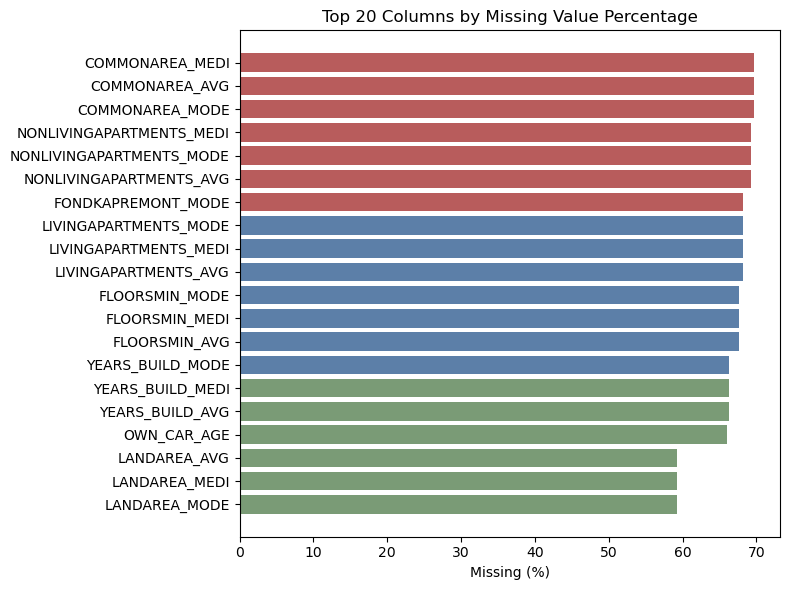

In [ ]:
top_missing = missing_summary.head(20)

# Muted colors: dusty red, slate blue, sage green
n = len(top_missing)
colors = []
for i in range(n):
    if i < n / 3:
        colors.append('#B85C5C')   # dusty red
    elif i < 2 * n / 3:
        colors.append('#5C7FA8')   # slate blue
    else:
        colors.append('#7A9B76')   # sage green

plt.figure(figsize=(8, 6))
plt.barh(top_missing.index, top_missing['missing_pct'], color=colors)
plt.xlabel('Missing (%)')
plt.title('Top 20 Columns by Missing Value Percentage')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('missing_values_chart.png', dpi=150)
plt.show()

(deciding methods to deal with missing values based on threshold strategy, breaking them into brackets depending about the no. of missing values)

In [ ]:
low_bracket = missing_summary[missing_summary['missing_pct'] < 20]
mid_bracket = missing_summary[(missing_summary['missing_pct'] >= 20) & (missing_summary['missing_pct']< 50)]
high_bracket = missing_summary[missing_summary['missing_pct'] >= 50]

print(f"<20% missing data: {len(low_bracket)} columns")
print(f"20-50% missing data: {len(mid_bracket)} columns")
print(f">=50% missing data: {len(high_bracket)} columns")

print(high_bracket.index.tolist())

<20% missing data: 17 columns
20-50% missing data: 13 columns
>=50% missing data: 37 columns
['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'FLOORSMIN_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'EXT_SOURCE_1', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'ELEVATORS_AVG', 'WALLSMATERIAL_MODE', 'APARTMENTS_MODE', 'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'ENTRANCES_MODE', 'ENTRANCES_AVG', 'ENTRANCES_MEDI']


(checking data types in high bracket before handling it)

In [ ]:
print(app_combined[high_bracket.index].dtypes.value_counts())

float64    35
object      2
Name: count, dtype: int64


(both data types will be dealt differently.splitting them according to the dtype)

In [ ]:
high_numeric = app_combined[high_bracket.index].select_dtypes(include='number').columns
high_categorical = app_combined[high_bracket.index].select_dtypes(include='object').columns
print(high_numeric)
print(high_categorical)

Index(['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE',
       'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE',
       'NONLIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MODE',
       'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_MODE',
       'FLOORSMIN_MEDI', 'FLOORSMIN_AVG', 'YEARS_BUILD_MODE',
       'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_AVG',
       'LANDAREA_MEDI', 'LANDAREA_MODE', 'BASEMENTAREA_MEDI',
       'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'NONLIVINGAREA_MEDI',
       'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'EXT_SOURCE_1',
       'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'ELEVATORS_AVG', 'APARTMENTS_MODE',
       'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'ENTRANCES_MODE', 'ENTRANCES_AVG',
       'ENTRANCES_MEDI'],
      dtype='object')
Index(['FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE'], dtype='object')


I. HIGH BRACKET

(filling the high bracket numeric columns)

(using only the median of "train" data to fill missing values of both training and test data rows)

(a _missing column is added to keep track of what vlaues were missing before, created just in case required for ML)

In [ ]:
skip_columns = ['OWN_CAR_AGE', 'EXT_SOURCE_1']

for col in high_numeric:
  if col in skip_columns:
    continue
 # app_combined[col + '_MISSING'] = app_combined[col].isnull().astype(int)
  train_rows = app_combined[app_combined['dataset_source'] == 'train']
  train_median = train_rows[col].median()
  app_combined[col] = app_combined[col].fillna(train_median)

(filling the two categorical columns in high bracket now)

In [ ]:
for col in high_categorical:
  app_combined[col] = app_combined[col].fillna('Missing')

(checking for car age col missing pattern and filling it accordingly)

(separated the cols with missing data of car age and checked using flag car if they own a car or not. majority of them dont own a car so filling with 0)

In [ ]:
no_car_age = app_combined[app_combined['OWN_CAR_AGE'].isnull()]
print(no_car_age['FLAG_OWN_CAR'].value_counts())
app_combined['OWN_CAR_AGE'] = app_combined['OWN_CAR_AGE'].fillna(0)

FLAG_OWN_CAR
N    235235
Y         6
Name: count, dtype: int64


In [ ]:
# app_combined['EXT_SOURCE_1_MISSING'] = app_combined['EXT_SOURCE_1'].isnull().astype(int)
train_rows = app_combined[app_combined['dataset_source'] == 'train']
train_median_ext1 = train_rows['EXT_SOURCE_1'].median()
app_combined['EXT_SOURCE_1'] = app_combined['EXT_SOURCE_1'].fillna(train_median_ext1)

II. MID BRACKET



In [ ]:
mid_numeric = app_combined[mid_bracket.index].select_dtypes(include='number').columns
mid_categorical = app_combined[mid_bracket.index].select_dtypes(include='object').columns
print(mid_numeric)
print(mid_categorical)

Index(['LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'LIVINGAREA_AVG',
       'FLOORSMAX_MEDI', 'FLOORSMAX_AVG', 'FLOORSMAX_MODE',
       'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI',
       'YEARS_BEGINEXPLUATATION_MODE', 'TOTALAREA_MODE'],
      dtype='object')
Index(['HOUSETYPE_MODE', 'EMERGENCYSTATE_MODE', 'OCCUPATION_TYPE'], dtype='object')


(filling both numeric and categorical missing values in a similar manner)

In [ ]:
for col in mid_numeric:
   # app_combined[col + '_MISSING'] = app_combined[col].isnull().astype(int)
    train_rows  = app_combined[app_combined['dataset_source'] == 'train']
    train_median_mid = train_rows[col].median()
    app_combined[col] = app_combined[col].fillna(train_median_mid)

In [ ]:
app_combined['HOUSETYPE_MODE'] = app_combined['HOUSETYPE_MODE'].fillna('Missing')
app_combined['EMERGENCYSTATE_MODE'] = app_combined['EMERGENCYSTATE_MODE'].fillna('Missing')
app_combined['OCCUPATION_TYPE'] = app_combined['OCCUPATION_TYPE'].fillna('Missing')

III. LOW BRACKET

(the columns in low bracket vary in the type of values so they will be dealt with in different ways)

(first is dealing with columns that have missing values that can be filled with median)

In [ ]:
median_fill_cols = ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'CNT_FAM_MEMBERS', 'DAYS_LAST_PHONE_CHANGE']

for col in median_fill_cols:
   # if col in ['EXT_SOURCE_2', 'EXT_SOURCE_3']:
       # app_combined[col + '_MISSING'] = app_combined[col].isnull().astype(int)
    train_rows = app_combined[app_combined['dataset_source'] == 'train']
    train_median = train_rows[col].median()
    app_combined[col] = app_combined[col].fillna(train_median)

(now handling columns where 0/1 values)

In [ ]:
zero_fill_cols = ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']

for col in zero_fill_cols:
    app_combined[col] = app_combined[col].fillna(0)

(the column with least missing values NAME_TYPE_SUITE and categorical values will be dealt with differently. using mode or the most common value for this)

In [ ]:
train_rows = app_combined[app_combined['dataset_source'] == 'train']
suite_mode = train_rows['NAME_TYPE_SUITE'].mode()[0]
app_combined['NAME_TYPE_SUITE'] = app_combined['NAME_TYPE_SUITE'].fillna(suite_mode)

(checking total missing values in the dF)

In [ ]:
total_missing = app_combined.isnull().sum().sum()
print(total_missing)

0


(working on other tables before joining the with the main train/test tables)

In [ ]:
bureau = pd.read_csv('data/bureau.csv')
bureau_balance = pd.read_csv('data/bureau_balance.csv')

print(bureau.shape)
print(bureau_balance.shape)

(1716428, 17)
(27299925, 3)


(the following shows there are multiple repeated values in the table)

In [ ]:
print(bureau['SK_ID_CURR'].nunique())
print(bureau['SK_ID_BUREAU'].nunique())

305811
1716428


In [ ]:
print(bureau_balance['SK_ID_BUREAU'].nunique())

817395


In [ ]:
print(bureau.isnull().sum()[bureau.isnull().sum() > 0])

DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_ANNUITY               1226791
dtype: int64


(this shows that the bureau_balance table has no missing values)

In [ ]:
print(bureau_balance.isnull().sum()[bureau_balance.isnull().sum() > 0])

Series([], dtype: int64)


In [ ]:
print(bureau_balance['STATUS'].value_counts())

STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64


In [ ]:
# checks whether the STATUS col has one of the following values in isin which shows how many months the loan is overdue
# int at the end assigns 1 to row whenever the vlaue 1-5 and 0 when the value C, X, or 0
bureau_balance['IS_DPD'] = bureau_balance['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

#grouping acc to SK_ID and counting all the monthly records for each ID
# is_dpd only has 0 and 1 so it'll only count the 1 and tell the no. of months of loan overdue
bureau_balance_agg = bureau_balance.groupby('SK_ID_BUREAU').agg(
    MONTHS_COUNT=('MONTHS_BALANCE', 'count'),
    DPD_MONTHS_COUNT=('IS_DPD', 'sum')
).reset_index()

print(bureau_balance_agg.shape)
bureau_balance_agg.head()

(817395, 3)


,SK_ID_BUREAU,MONTHS_COUNT,DPD_MONTHS_COUNT
0,5001709,97,0
1,5001710,83,0
2,5001711,4,0
3,5001712,19,0
4,5001713,22,0


(merging with bureau)

In [ ]:
# left join, returns all left table values and the ones from right table that match the ID
bureau = bureau.merge(bureau_balance_agg, on='SK_ID_BUREAU', how='left')
print(bureau.shape)
bureau.head()

(1716428, 19)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,MONTHS_COUNT,DPD_MONTHS_COUNT
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN,NaN,NaN


In [ ]:
print(bureau['MONTHS_COUNT'].isnull().sum())
print(bureau['DPD_MONTHS_COUNT'].isnull().sum())

942074
942074


(filling the last two columns with 0)

In [ ]:
bureau['MONTHS_COUNT'] = bureau['MONTHS_COUNT'].fillna(0)
bureau['DPD_MONTHS_COUNT'] = bureau['DPD_MONTHS_COUNT'].fillna(0)

(filling the missing values in bureau column)

In [ ]:
bureau.isnull().sum()


SK_ID_CURR                      0
SK_ID_BUREAU                    0
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
MONTHS_COUNT                    0
DPD_MONTHS_COUNT                0
dtype: int64

In [ ]:
bureau_updated = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_COUNT=('SK_ID_BUREAU', 'count'),
    DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    AMT_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    AMT_CREDIT_SUM_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    AMT_CREDIT_SUM_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', 'sum'),
    AMT_CREDIT_SUM_OVERDUE_MEAN=('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    AMT_CREDIT_MAX_OVERDUE_MEAN=('AMT_CREDIT_MAX_OVERDUE', 'mean'),
    CNT_CREDIT_PROLONG_SUM=('CNT_CREDIT_PROLONG', 'sum'),
    MONTHS_COUNT_SUM=('MONTHS_COUNT', 'sum'),
    DPD_MONTHS_COUNT_SUM=('DPD_MONTHS_COUNT', 'sum')
).reset_index()

print(bureau_updated.shape)
bureau_updated.head()

(305811, 12)


,SK_ID_CURR,BUREAU_COUNT,DAYS_CREDIT_MEAN,CREDIT_DAY_OVERDUE_MAX,AMT_CREDIT_SUM_MEAN,AMT_CREDIT_SUM_DEBT_MEAN,AMT_CREDIT_SUM_DEBT_SUM,AMT_CREDIT_SUM_OVERDUE_MEAN,AMT_CREDIT_MAX_OVERDUE_MEAN,CNT_CREDIT_PROLONG_SUM,MONTHS_COUNT_SUM,DPD_MONTHS_COUNT_SUM
0,100001,7,-735.000000,0,207623.571429,85240.928571,596686.5,0.0,NaN,0,172.0,1.0
1,100002,8,-874.000000,0,108131.945625,49156.200000,245781.0,0.0,1681.029,0,110.0,27.0
2,100003,4,-1400.750000,0,254350.125000,0.000000,0.0,0.0,0.000,0,0.0,0.0
3,100004,2,-867.000000,0,94518.900000,0.000000,0.0,0.0,0.000,0,0.0,0.0
4,100005,3,-190.666667,0,219042.000000,189469.500000,568408.5,0.0,0.000,0,21.0,0.0


In [ ]:
print(bureau_updated.shape[0])
print(bureau['SK_ID_CURR'].nunique())

305811
305811


In [ ]:
print(bureau_updated.isnull().sum())

SK_ID_CURR                         0
BUREAU_COUNT                       0
DAYS_CREDIT_MEAN                   0
CREDIT_DAY_OVERDUE_MAX             0
AMT_CREDIT_SUM_MEAN                2
AMT_CREDIT_SUM_DEBT_MEAN        8372
AMT_CREDIT_SUM_DEBT_SUM            0
AMT_CREDIT_SUM_OVERDUE_MEAN        0
AMT_CREDIT_MAX_OVERDUE_MEAN    92840
CNT_CREDIT_PROLONG_SUM             0
MONTHS_COUNT_SUM                   0
DPD_MONTHS_COUNT_SUM               0
dtype: int64


In [ ]:
bureau_cols_to_fill = bureau_updated.columns.drop('SK_ID_CURR')

for col in bureau_cols_to_fill:
    bureau_updated[col] = bureau_updated[col].fillna(0)

(merging the final updated bureau with app_combined using left join again)

In [ ]:
app_combined = app_combined.merge(bureau_updated, on='SK_ID_CURR', how='left')
print(app_combined.shape)

(356255, 133)


In [ ]:
bureau_feature_cols = bureau_updated.columns.drop('SK_ID_CURR')

for col in bureau_feature_cols:
    app_combined[col] = app_combined[col].fillna(0)

(cleaning previous_application table)

In [ ]:
previous_application = pd.read_csv('data/previous_application.csv')
pos_cash = pd.read_csv('data/POS_CASH_balance.csv')
credit_card = pd.read_csv('data/credit_card_balance.csv')
installments = pd.read_csv('data/installments_payments.csv')

print(previous_application.shape)
print(pos_cash.shape)
print(credit_card.shape)
print(installments.shape)

(1670214, 37)
(10001358, 8)
(3840312, 23)
(13605401, 8)


In [ ]:
print(previous_application.shape)
print(previous_application['SK_ID_CURR'].nunique())
print(previous_application['SK_ID_PREV'].nunique())

missing = previous_application.isnull().sum()
missing_pct = (missing / len(previous_application)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_summary)

(1670214, 37)
338857
1670214
                           missing_count  missing_pct
RATE_INTEREST_PRIMARY            1664263    99.643698
RATE_INTEREST_PRIVILEGED         1664263    99.643698
AMT_DOWN_PAYMENT                  895844    53.636480
RATE_DOWN_PAYMENT                 895844    53.636480
NAME_TYPE_SUITE                   820405    49.119754
DAYS_FIRST_DRAWING                673065    40.298129
DAYS_FIRST_DUE                    673065    40.298129
DAYS_LAST_DUE_1ST_VERSION         673065    40.298129
DAYS_LAST_DUE                     673065    40.298129
DAYS_TERMINATION                  673065    40.298129
NFLAG_INSURED_ON_APPROVAL         673065    40.298129
AMT_GOODS_PRICE                   385515    23.081773
AMT_ANNUITY                       372235    22.286665
CNT_PAYMENT                       372230    22.286366
PRODUCT_COMBINATION                  346     0.020716
AMT_CREDIT                             1     0.000060


In [ ]:
low_bracket = missing_summary[missing_summary['missing_pct'] < 20]
mid_bracket = missing_summary[(missing_summary['missing_pct'] >= 20) & (missing_summary['missing_pct'] < 50)]
high_bracket = missing_summary[missing_summary['missing_pct'] >= 50]

print(f"<20% missing: {len(low_bracket)} columns")
print(f"20-50% missing: {len(mid_bracket)} columns")
print(f">=50% missing: {len(high_bracket)} columns")
print(high_bracket.index.tolist())

<20% missing: 2 columns
20-50% missing: 10 columns
>=50% missing: 4 columns
['RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'AMT_DOWN_PAYMENT', 'RATE_DOWN_PAYMENT']


I. **HIGH** **BRACKET**
(RATE_INTEREST_PRIVILEGED and RATE_INTEREST_PRIMARY are ~99.6% missing, too sparse to fill reliably, so these columns are dropped)
(AMT_DOWN_PAYMENT and RATE_DOWN_PAYMENT are filled with 0, since missing likely means no down payment was made)

In [ ]:
# Drop the two columns that are ~99.6% missing — too sparse to use
previous_application = previous_application.drop(columns=['RATE_INTEREST_PRIVILEGED', 'RATE_INTEREST_PRIMARY'])

# Fill down payment columns with 0 (missing likely means no down payment made)
previous_application['AMT_DOWN_PAYMENT'] = previous_application['AMT_DOWN_PAYMENT'].fillna(0)
previous_application['RATE_DOWN_PAYMENT'] = previous_application['RATE_DOWN_PAYMENT'].fillna(0)

print(previous_application.shape)

(1670214, 35)


II. **MID** **BRACKET**
(checking if missing values in DAYS_* columns follow a pattern based on contract status)

In [ ]:
print(previous_application['NAME_CONTRACT_STATUS'].value_counts())

days_missing_mask = previous_application['DAYS_LAST_DUE'].isnull()
print(previous_application[days_missing_mask]['NAME_CONTRACT_STATUS'].value_counts())

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64
NAME_CONTRACT_STATUS
Canceled        316319
Refused         290678
Approved         39632
Unused offer     26436
Name: count, dtype: int64


In [ ]:
# These DAYS columns are missing when the loan never reached that stage (Canceled/Refused/Unused)
# Fill with 0 as a "not applicable" flag rather than median (median would fabricate fake timelines)
days_cols = ['DAYS_LAST_DUE', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE',
             'DAYS_TERMINATION', 'DAYS_LAST_DUE_1ST_VERSION']

for col in days_cols:
  #first filling the unusual/sentinel values 365243 to null
    previous_application[col] = previous_application[col].replace(365243, np.nan)
    previous_application[col] = previous_application[col].fillna(0)

# NFLAG_INSURED_ON_APPROVAL is also missing for non-approved loans — fill with 0 (not insured/not applicable)
previous_application['NFLAG_INSURED_ON_APPROVAL'] = previous_application['NFLAG_INSURED_ON_APPROVAL'].fillna(0)

print(previous_application[days_cols + ['NFLAG_INSURED_ON_APPROVAL']].isnull().sum())

DAYS_LAST_DUE                0
DAYS_FIRST_DRAWING           0
DAYS_FIRST_DUE               0
DAYS_TERMINATION             0
DAYS_LAST_DUE_1ST_VERSION    0
NFLAG_INSURED_ON_APPROVAL    0
dtype: int64


In [ ]:
previous_application_agg = previous_application.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT=('SK_ID_PREV', 'count'),
    AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    AMT_APPLICATION_MEAN=('AMT_APPLICATION', 'mean'),
    AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    AMT_DOWN_PAYMENT_MEAN=('AMT_DOWN_PAYMENT', 'mean'),
    AMT_GOODS_PRICE_MEAN=('AMT_GOODS_PRICE', 'mean'),
    CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
    DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    NFLAG_INSURED_ON_APPROVAL_SUM=('NFLAG_INSURED_ON_APPROVAL', 'sum')
).reset_index()

prev_app_cols = previous_application_agg.columns.drop('SK_ID_CURR')
for col in prev_app_cols:
    previous_application_agg[col] = previous_application_agg[col].fillna(0)

print(previous_application_agg.shape)

(338857, 10)


In [ ]:
app_combined = app_combined.merge(previous_application_agg, on='SK_ID_CURR', how='left')

for col in prev_app_cols:
    app_combined[col] = app_combined[col].fillna(0)

print(app_combined.shape)

(356255, 142)


In [ ]:
# check no sentinel values (365243) remain anywhere in the table
# sentinel_check = (previous_application == 365243).sum().sum()
# print("Remaining 365243 sentinel values across whole table:", sentinel_check)

# confirm no missing values remain anywhere in the table
# missing_check = previous_application.isnull().sum().sum()
# print("Remaining missing values across whole table:", missing_check)

# print("Shape:", previous_application.shape)


In [ ]:
# Categorical — fill with 'Missing'
previous_application['NAME_TYPE_SUITE'] = previous_application['NAME_TYPE_SUITE'].fillna('Missing')

# Numeric — fill with median
numeric_median_cols = ['AMT_GOODS_PRICE', 'AMT_ANNUITY', 'CNT_PAYMENT']
for col in numeric_median_cols:
    median_val = previous_application[col].median()
    previous_application[col] = previous_application[col].fillna(median_val)

print(previous_application[['NAME_TYPE_SUITE'] + numeric_median_cols].isnull().sum())

NAME_TYPE_SUITE    0
AMT_GOODS_PRICE    0
AMT_ANNUITY        0
CNT_PAYMENT        0
dtype: int64


III. **LOW** **BRACKET**
(the columns in low bracket vary in type, dealt with individually — PRODUCT_COMBINATION filled with mode/'Missing', AMT_CREDIT filled with median since only 1 row is affected)

In [ ]:
previous_application['PRODUCT_COMBINATION'] = previous_application['PRODUCT_COMBINATION'].fillna('Missing')

median_credit = previous_application['AMT_CREDIT'].median()
previous_application['AMT_CREDIT'] = previous_application['AMT_CREDIT'].fillna(median_credit)

# Final check — total missing values in the whole table
total_missing = previous_application.isnull().sum().sum()
print(total_missing)

0


**POS_CASH_balance**.**csv**

In [ ]:
print(pos_cash.shape)
print(pos_cash['SK_ID_CURR'].nunique())
print(pos_cash['SK_ID_PREV'].nunique())

missing = pos_cash.isnull().sum()
missing_pct = (missing / len(pos_cash)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_summary)

(10001358, 8)
337252
936325
                       missing_count  missing_pct
CNT_INSTALMENT_FUTURE          26087     0.260835
CNT_INSTALMENT                 26071     0.260675


In [ ]:
pos_cash['CNT_INSTALMENT'] = pos_cash['CNT_INSTALMENT'].fillna(pos_cash['CNT_INSTALMENT'].median())
pos_cash['CNT_INSTALMENT_FUTURE'] = pos_cash['CNT_INSTALMENT_FUTURE'].fillna(pos_cash['CNT_INSTALMENT_FUTURE'].median())

total_missing = pos_cash.isnull().sum().sum()
print(total_missing)

0


In [ ]:
pos_cash_agg = pos_cash.groupby('SK_ID_CURR').agg(
    POS_COUNT=('SK_ID_PREV', 'count'),
    MONTHS_BALANCE_MEAN=('MONTHS_BALANCE', 'mean'),
    CNT_INSTALMENT_MEAN=('CNT_INSTALMENT', 'mean'),
    CNT_INSTALMENT_FUTURE_MEAN=('CNT_INSTALMENT_FUTURE', 'mean'),
    SK_DPD_MEAN=('SK_DPD', 'mean'),
    SK_DPD_MAX=('SK_DPD', 'max'),
    SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean'),
    SK_DPD_DEF_MAX=('SK_DPD_DEF', 'max')
).reset_index()

pos_cash_agg = pos_cash_agg.rename(columns={
    'SK_DPD_MEAN': 'POS_SK_DPD_MEAN',
    'SK_DPD_MAX': 'POS_SK_DPD_MAX',
    'SK_DPD_DEF_MEAN': 'POS_SK_DPD_DEF_MEAN',
    'SK_DPD_DEF_MAX': 'POS_SK_DPD_DEF_MAX'
})

print(pos_cash_agg.shape)

(337252, 9)


In [ ]:
app_combined = app_combined.merge(pos_cash_agg, on='SK_ID_CURR', how='left')

pos_cash_cols = pos_cash_agg.columns.drop('SK_ID_CURR')
for col in pos_cash_cols:
    app_combined[col] = app_combined[col].fillna(0)

print(app_combined.shape)

(356255, 150)


**credit_card_balance**.**csv**

In [ ]:
print(credit_card.shape)
print(credit_card['SK_ID_CURR'].nunique())
print(credit_card['SK_ID_PREV'].nunique())

missing = credit_card.isnull().sum()
missing_pct = (missing / len(credit_card)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_summary)

(3840312, 23)
103558
104307
                            missing_count  missing_pct
AMT_PAYMENT_CURRENT                767988    19.998063
AMT_DRAWINGS_ATM_CURRENT           749816    19.524872
AMT_DRAWINGS_OTHER_CURRENT         749816    19.524872
AMT_DRAWINGS_POS_CURRENT           749816    19.524872
CNT_DRAWINGS_ATM_CURRENT           749816    19.524872
CNT_DRAWINGS_OTHER_CURRENT         749816    19.524872
CNT_DRAWINGS_POS_CURRENT           749816    19.524872
AMT_INST_MIN_REGULARITY            305236     7.948208
CNT_INSTALMENT_MATURE_CUM          305236     7.948208


In [ ]:
# Drawing-related columns: missing likely means no drawings that month → fill with 0
zero_fill_cols = ['AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT',
                   'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT']

for col in zero_fill_cols:
    credit_card[col] = credit_card[col].fillna(0)

In [ ]:
credit_card_agg = credit_card.groupby('SK_ID_CURR').agg(
    CC_COUNT=('SK_ID_PREV', 'count'),
    AMT_BALANCE_MEAN=('AMT_BALANCE', 'mean'),
    AMT_CREDIT_LIMIT_ACTUAL_MEAN=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    AMT_DRAWINGS_ATM_CURRENT_SUM=('AMT_DRAWINGS_ATM_CURRENT', 'sum'),
    AMT_DRAWINGS_CURRENT_SUM=('AMT_DRAWINGS_CURRENT', 'sum'),
    AMT_PAYMENT_CURRENT_MEAN=('AMT_PAYMENT_CURRENT', 'mean'),
    AMT_INST_MIN_REGULARITY_MEAN=('AMT_INST_MIN_REGULARITY', 'mean'),
    CNT_DRAWINGS_CURRENT_SUM=('CNT_DRAWINGS_CURRENT', 'sum'),
    SK_DPD_MEAN=('SK_DPD', 'mean'),
    SK_DPD_MAX=('SK_DPD', 'max'),
    SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean')
).reset_index()

credit_card_agg = credit_card_agg.rename(columns={
    'SK_DPD_MEAN': 'CC_SK_DPD_MEAN',
    'SK_DPD_MAX': 'CC_SK_DPD_MAX',
    'SK_DPD_DEF_MEAN': 'CC_SK_DPD_DEF_MEAN'
})

cc_cols = credit_card_agg.columns.drop('SK_ID_CURR')
for col in cc_cols:
    credit_card_agg[col] = credit_card_agg[col].fillna(0)

print(credit_card_agg.shape)

(103558, 12)


In [ ]:
app_combined = app_combined.merge(credit_card_agg, on='SK_ID_CURR', how='left')

for col in cc_cols:
    app_combined[col] = app_combined[col].fillna(0)

print(app_combined.shape)

(356255, 161)


In [ ]:
median_fill_cols = ['AMT_PAYMENT_CURRENT', 'AMT_INST_MIN_REGULARITY', 'CNT_INSTALMENT_MATURE_CUM']
for col in median_fill_cols:
    credit_card[col] = credit_card[col].fillna(credit_card[col].median())

print(credit_card.isnull().sum().sum())

0


**installments_payments**.**csv**

In [ ]:
print(installments.shape)
print(installments['SK_ID_CURR'].nunique())
print(installments['SK_ID_PREV'].nunique())

missing = installments.isnull().sum()
missing_pct = (missing / len(installments)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_summary)

(13605401, 8)
339587
997752
                    missing_count  missing_pct
DAYS_ENTRY_PAYMENT           2905     0.021352
AMT_PAYMENT                  2905     0.021352


In [ ]:
installments['DAYS_ENTRY_PAYMENT'] = installments['DAYS_ENTRY_PAYMENT'].fillna(0)
installments['AMT_PAYMENT'] = installments['AMT_PAYMENT'].fillna(0)

total_missing = installments.isnull().sum().sum()
print(total_missing)

0


In [ ]:
installments_agg = installments.groupby('SK_ID_CURR').agg(
    INSTALLMENT_COUNT=('SK_ID_PREV', 'count'),
    DAYS_INSTALMENT_MEAN=('DAYS_INSTALMENT', 'mean'),
    DAYS_ENTRY_PAYMENT_MEAN=('DAYS_ENTRY_PAYMENT', 'mean'),
    AMT_INSTALMENT_MEAN=('AMT_INSTALMENT', 'mean'),
    AMT_INSTALMENT_SUM=('AMT_INSTALMENT', 'sum'),
    AMT_PAYMENT_MEAN=('AMT_PAYMENT', 'mean'),
    AMT_PAYMENT_SUM=('AMT_PAYMENT', 'sum')
).reset_index()

app_combined = app_combined.merge(installments_agg, on='SK_ID_CURR', how='left')

installments_cols = installments_agg.columns.drop('SK_ID_CURR')
for col in installments_cols:
    app_combined[col] = app_combined[col].fillna(0)

print(app_combined.shape)

(356255, 168)


In [ ]:
# Final shape check
print("Final shape:", app_combined.shape)

# Total missing values across the entire combined dataset
total_missing = app_combined.isnull().sum().sum()
print("Total missing values:", total_missing)

# Confirm row count still matches original train+test combined (no duplicates introduced)
print("Expected rows:", 307511 + 48744)

# Confirm dataset_source still splits correctly
print(app_combined['dataset_source'].value_counts())

# Check for any duplicate rows
print("Duplicate rows:", app_combined.duplicated().sum())

Final shape: (356255, 168)
Total missing values: 0
Expected rows: 356255
dataset_source
train    307511
test      48744
Name: count, dtype: int64
Duplicate rows: 0


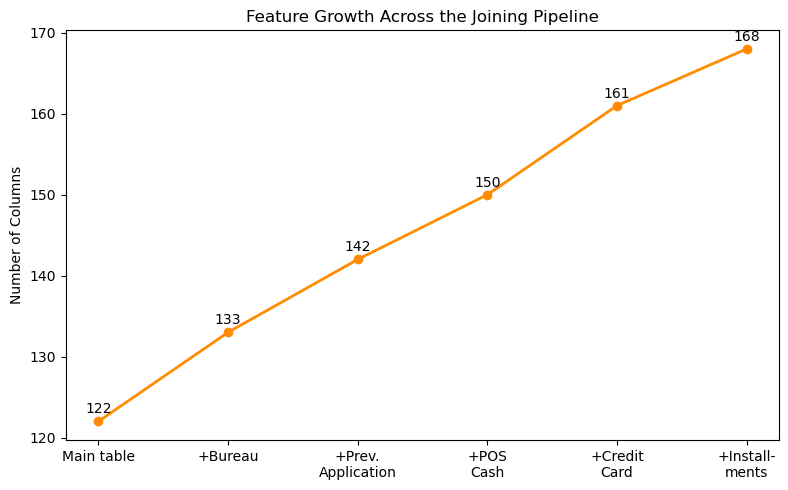

In [ ]:
stages = ['Main table', '+Bureau', '+Prev.\nApplication', '+POS\nCash', '+Credit\nCard', '+Install-\nments']
col_counts = [122, 133, 142, 150, 161, 168]

plt.figure(figsize=(8, 5))
plt.plot(stages, col_counts, marker='o', color='darkorange', linewidth=2)
for i, count in enumerate(col_counts):
    plt.text(i, count + 1, str(count), ha='center')
plt.ylabel('Number of Columns')
plt.title('Feature Growth Across the Joining Pipeline')
plt.tight_layout()
plt.savefig('column_growth_chart.png', dpi=150)
plt.show()

In [ ]:
app_combined.to_csv('data/app_combined_cleaned.csv', index=False)
print("Saved successfully")

Saved successfully


In [ ]:
train_target.to_csv('data/train_target.csv', index=False)
print("Saved successfully")

Saved successfully


#### II. ML Model

In [ ]:
# Cleaned feature dataset
df = pd.read_csv('data/app_combined_cleaned.csv')

# Target
target = pd.read_csv('data/train_target.csv')

print("Features:", df.shape)
print("Target:", target.shape)

Features: (356255, 168)
Target: (307511, 1)


In [ ]:
print("=" * 70)
print("1. DATASET SHAPE")
print("=" * 70)
print("Feature dataset:", df.shape)
print("Target dataset :", target.shape)

print("\n" + "=" * 70)
print("2. FIRST 5 ROWS")
print("=" * 70)
display(df.head())

print("\n" + "=" * 70)
print("3. COLUMN NAMES")
print("=" * 70)
for i, col in enumerate(df.columns, 1):
    print(f"{i:3}. {col}")

print("\n" + "=" * 70)
print("4. DATA TYPES")
print("=" * 70)
print(df.dtypes.value_counts())

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f"\nNumerical columns   : {len(numerical_cols)}")
print(f"Categorical columns : {len(categorical_cols)}")

print("\nCategorical columns:")
print(categorical_cols)

print("\n" + "=" * 70)
print("5. ID CHECK")
print("=" * 70)

print("SK_ID_CURR present:", "SK_ID_CURR" in df.columns)

if "SK_ID_CURR" in df.columns:
    print("Unique applicants:", df["SK_ID_CURR"].nunique())
    print("Duplicate IDs:", df["SK_ID_CURR"].duplicated().sum())

print("\nDuplicate complete rows:", df.duplicated().sum())

print("\n" + "=" * 70)
print("6. TARGET CHECK")
print("=" * 70)

print(target["TARGET"].value_counts())
print("\nPercentages:")
print((target["TARGET"].value_counts(normalize=True) * 100).round(2))

print("\nFeature rows == target rows:", len(df) == len(target))

print("\n" + "=" * 70)
print("7. MISSING VALUES")
print("=" * 70)

missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

missing = missing[missing["missing_count"] > 0].sort_values(
    "missing_percent", ascending=False
)

print("Columns containing missing values:", len(missing))
display(missing.head(50))

print("\n" + "=" * 70)
print("8. INFINITE VALUES")
print("=" * 70)

numeric_df = df[numerical_cols]

inf_counts = np.isinf(numeric_df).sum()
inf_counts = inf_counts[inf_counts > 0].sort_values(ascending=False)

print("Columns containing +/- infinity:", len(inf_counts))
display(inf_counts)

print("\n" + "=" * 70)
print("9. CONSTANT / NEAR-CONSTANT FEATURES")
print("=" * 70)

nunique = df.nunique(dropna=False)

constant_cols = nunique[nunique <= 1].index.tolist()

print("Constant columns:", len(constant_cols))
print(constant_cols)

print("\n" + "=" * 70)
print("10. MEMORY USAGE")
print("=" * 70)

memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"DataFrame memory usage: {memory_mb:.2f} MB")

1. DATASET SHAPE
Feature dataset: (356255, 168)
Target dataset : (307511, 1)

2. FIRST 5 ROWS


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_SK_DPD_MEAN,CC_SK_DPD_MAX,CC_SK_DPD_DEF_MEAN,INSTALLMENT_COUNT,DAYS_INSTALMENT_MEAN,DAYS_ENTRY_PAYMENT_MEAN,AMT_INSTALMENT_MEAN,AMT_INSTALMENT_SUM,AMT_PAYMENT_MEAN,AMT_PAYMENT_SUM
0,100002,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0.0,0.0,0.0,19.0,-295.000000,-315.421053,11559.247105,219625.695,11559.247105,219625.695
1,100003,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,0.0,0.0,25.0,-1378.160000,-1385.320000,64754.586000,1618864.650,64754.586000,1618864.650
2,100004,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,3.0,-754.000000,-761.666667,7096.155000,21288.465,7096.155000,21288.465
3,100006,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,16.0,-252.250000,-271.625000,62947.088438,1007153.415,62947.088438,1007153.415
4,100007,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.0,0.0,66.0,-1028.606061,-1032.242424,12666.444545,835985.340,12214.060227,806127.975



3. COLUMN NAMES
  1. SK_ID_CURR
  2. NAME_CONTRACT_TYPE
  3. CODE_GENDER
  4. FLAG_OWN_CAR
  5. FLAG_OWN_REALTY
  6. CNT_CHILDREN
  7. AMT_INCOME_TOTAL
  8. AMT_CREDIT
  9. AMT_ANNUITY
 10. AMT_GOODS_PRICE
 11. NAME_TYPE_SUITE
 12. NAME_INCOME_TYPE
 13. NAME_EDUCATION_TYPE
 14. NAME_FAMILY_STATUS
 15. NAME_HOUSING_TYPE
 16. REGION_POPULATION_RELATIVE
 17. DAYS_BIRTH
 18. DAYS_EMPLOYED
 19. DAYS_REGISTRATION
 20. DAYS_ID_PUBLISH
 21. OWN_CAR_AGE
 22. FLAG_MOBIL
 23. FLAG_EMP_PHONE
 24. FLAG_WORK_PHONE
 25. FLAG_CONT_MOBILE
 26. FLAG_PHONE
 27. FLAG_EMAIL
 28. OCCUPATION_TYPE
 29. CNT_FAM_MEMBERS
 30. REGION_RATING_CLIENT
 31. REGION_RATING_CLIENT_W_CITY
 32. WEEKDAY_APPR_PROCESS_START
 33. HOUR_APPR_PROCESS_START
 34. REG_REGION_NOT_LIVE_REGION
 35. REG_REGION_NOT_WORK_REGION
 36. LIVE_REGION_NOT_WORK_REGION
 37. REG_CITY_NOT_LIVE_CITY
 38. REG_CITY_NOT_WORK_CITY
 39. LIVE_CITY_NOT_WORK_CITY
 40. ORGANIZATION_TYPE
 41. EXT_SOURCE_1
 42. EXT_SOURCE_2
 43. EXT_SOURCE_3
 44. APARTMENTS_AV

,missing_count,missing_percent



8. INFINITE VALUES
Columns containing +/- infinity: 0


Series([], dtype: int64)


9. CONSTANT / NEAR-CONSTANT FEATURES
Constant columns: 1
['AMT_DRAWINGS_ATM_CURRENT_SUM']

10. MEMORY USAGE
DataFrame memory usage: 745.89 MB


In [ ]:
print(df["dataset_source"].value_counts(dropna=False))

dataset_source
train    307511
test      48744
Name: count, dtype: int64


In [ ]:
print("dataset_source distribution:")
print(df["dataset_source"].value_counts())

# Separate Kaggle train and test applicants
train_df = df[df["dataset_source"] == "train"].copy()
test_df  = df[df["dataset_source"] == "test"].copy()

print("\nTrain features:", train_df.shape)
print("Test features :", test_df.shape)
print("Target        :", target.shape)

assert len(train_df) == len(target), \
    "Train rows and TARGET rows do not match!"

# Attach target only to training applicants
train_df["TARGET"] = target["TARGET"].values

print("\nTARGET distribution:")
print(train_df["TARGET"].value_counts())
print(train_df["TARGET"].value_counts(normalize=True).round(4))

dataset_source distribution:
dataset_source
train    307511
test      48744
Name: count, dtype: int64

Train features: (307511, 168)
Test features : (48744, 168)
Target        : (307511, 1)

TARGET distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


In [ ]:
def engineer_features(data):
    data = data.copy()

    eps = 1e-6
    # Credit requested relative to applicant income
    data["FE_CREDIT_INCOME_RATIO"] = (
        data["AMT_CREDIT"] / (data["AMT_INCOME_TOTAL"] + eps)
    )

    # Annualized loan payment burden relative to income
    data["FE_ANNUITY_INCOME_RATIO"] = (
        data["AMT_ANNUITY"] / (data["AMT_INCOME_TOTAL"] + eps)
    )

    # Approximate length/burden of loan
    data["FE_CREDIT_ANNUITY_RATIO"] = (
        data["AMT_CREDIT"] / (data["AMT_ANNUITY"] + eps)
    )

    # How much of the goods price is financed
    data["FE_CREDIT_GOODS_RATIO"] = (
        data["AMT_CREDIT"] / (data["AMT_GOODS_PRICE"] + eps)
    )

    # Income adjusted for household size
    data["FE_INCOME_PER_PERSON"] = (
        data["AMT_INCOME_TOTAL"] / (data["CNT_FAM_MEMBERS"] + eps)
    )
    data["FE_AGE_YEARS"] = abs(data["DAYS_BIRTH"]) / 365.25

    data["FE_EMPLOYED_YEARS"] = abs(data["DAYS_EMPLOYED"]) / 365.25

    data["FE_EMPLOYED_AGE_RATIO"] = (
        abs(data["DAYS_EMPLOYED"]) /
        (abs(data["DAYS_BIRTH"]) + eps)
    )

    ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

    data["FE_EXT_SOURCE_MEAN"] = data[ext_cols].mean(axis=1)

    data["FE_EXT_SOURCE_MIN"] = data[ext_cols].min(axis=1)

    data["FE_EXT_SOURCE_MAX"] = data[ext_cols].max(axis=1)

    data["FE_EXT_SOURCE_STD"] = data[ext_cols].std(axis=1)

    data["FE_BUREAU_DEBT_CREDIT_RATIO"] = (
        data["AMT_CREDIT_SUM_DEBT_SUM"] /
        ((data["AMT_CREDIT_SUM_MEAN"] * data["BUREAU_COUNT"]) + eps)
    )
    data["FE_BUREAU_OVERDUE_PER_LOAN"] = (
        data["AMT_CREDIT_SUM_OVERDUE_MEAN"] /
        (data["BUREAU_COUNT"] + eps)
    )
    data["FE_CREDIT_PROLONG_RATE"] = (
        data["CNT_CREDIT_PROLONG_SUM"] /
        (data["BUREAU_COUNT"] + eps)
    )
    data["FE_PREV_CREDIT_APPLICATION_RATIO"] = (
        data["AMT_CREDIT_MEAN"] /
        (data["AMT_APPLICATION_MEAN"] + eps)
    )
    data["FE_PREV_ANNUITY_CREDIT_RATIO"] = (
        data["AMT_ANNUITY_MEAN"] /
        (data["AMT_CREDIT_MEAN"] + eps)
    )
    data["FE_CC_UTILIZATION"] = (
        data["AMT_BALANCE_MEAN"] /
        (data["AMT_CREDIT_LIMIT_ACTUAL_MEAN"] + eps)
    )
    data["FE_CC_DRAWING_RATIO"] = (
        data["AMT_DRAWINGS_CURRENT_SUM"] /
        (data["AMT_CREDIT_LIMIT_ACTUAL_MEAN"] + eps)
    )
    data["FE_CC_DPD_RATE"] = (
        data["CC_SK_DPD_MEAN"] /
        (data["CC_COUNT"] + eps)
    )
    data["FE_PAYMENT_RATIO"] = (
        data["AMT_PAYMENT_SUM"] /
        (data["AMT_INSTALMENT_SUM"] + eps)
    )
    data["FE_PAYMENT_DIFFERENCE"] = (
        data["AMT_PAYMENT_SUM"] -
        data["AMT_INSTALMENT_SUM"]
    )
    # Positive value roughly represents later payment
    data["FE_PAYMENT_DELAY"] = (
        data["DAYS_ENTRY_PAYMENT_MEAN"] -
        data["DAYS_INSTALMENT_MEAN"]
    )
    data["FE_POS_DPD_RATE"] = (
        data["POS_SK_DPD_MEAN"] /
        (data["POS_COUNT"] + eps)
    )
    data.replace([np.inf, -np.inf], np.nan, inplace=True)

    return data

In [ ]:
print("DATASET SOURCE")
print(df["dataset_source"].value_counts(dropna=False))

print("\nDAYS_EMPLOYED SUMMARY")
print(df["DAYS_EMPLOYED"].describe())

print("\n365243 sentinel count:")
print((df["DAYS_EMPLOYED"] == 365243).sum())

print("\nLargest DAYS_EMPLOYED values:")
print(df["DAYS_EMPLOYED"].nlargest(10).values)

DATASET SOURCE
dataset_source
train    307511
test      48744
Name: count, dtype: int64

DAYS_EMPLOYED SUMMARY
count    356255.000000
mean      64317.231413
std      141705.532576
min      -17912.000000
25%       -2781.000000
50%       -1224.000000
75%        -290.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

365243 sentinel count:
64648

Largest DAYS_EMPLOYED values:
[365243 365243 365243 365243 365243 365243 365243 365243 365243 365243]


In [ ]:
# Separate train and test applicants
train_df = df[df["dataset_source"] == "train"].copy()
test_df  = df[df["dataset_source"] == "test"].copy()

print("Train:", train_df.shape)
print("Test :", test_df.shape)

# Verify target alignment
assert len(train_df) == len(target), \
    "ERROR: Training features and target do not have equal rows."

# Attach TARGET only to training observations
train_df["TARGET"] = target["TARGET"].values

print("\nTarget successfully attached.")
print(train_df["TARGET"].value_counts())
print("\nTarget percentages:")
print((train_df["TARGET"].value_counts(normalize=True) * 100).round(2))

Train: (307511, 168)
Test : (48744, 168)

Target successfully attached.
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentages:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [ ]:
def fix_days_employed(data):
    data = data.copy()

    # Flag applicants with the anomalous sentinel value
    data["FE_EMPLOYMENT_UNKNOWN"] = (
        data["DAYS_EMPLOYED"] == 365243
    ).astype("int8")

    # Replace impossible sentinel with NaN
    data.loc[
        data["DAYS_EMPLOYED"] == 365243,
        "DAYS_EMPLOYED"
    ] = np.nan

    return data


train_df = fix_days_employed(train_df)
test_df  = fix_days_employed(test_df)

print("Training anomalies remaining:",
      (train_df["DAYS_EMPLOYED"] == 365243).sum())

print("Test anomalies remaining:",
      (test_df["DAYS_EMPLOYED"] == 365243).sum())

print("\nEmployment unknown:")
print(train_df["FE_EMPLOYMENT_UNKNOWN"].value_counts())

Training anomalies remaining: 0
Test anomalies remaining: 0

Employment unknown:
FE_EMPLOYMENT_UNKNOWN
0    252137
1     55374
Name: count, dtype: int64


In [ ]:
def add_application_features(data):
    data = data.copy()

    # Avoid division by zero
    eps = 1e-6

    # -------------------------
    # Financial burden features
    # -------------------------

    data["FE_CREDIT_INCOME_RATIO"] = (
        data["AMT_CREDIT"] /
        (data["AMT_INCOME_TOTAL"] + eps)
    )

    data["FE_ANNUITY_INCOME_RATIO"] = (
        data["AMT_ANNUITY"] /
        (data["AMT_INCOME_TOTAL"] + eps)
    )

    data["FE_CREDIT_ANNUITY_RATIO"] = (
        data["AMT_CREDIT"] /
        (data["AMT_ANNUITY"] + eps)
    )

    data["FE_CREDIT_GOODS_RATIO"] = (
        data["AMT_CREDIT"] /
        (data["AMT_GOODS_PRICE"] + eps)
    )
    data["FE_INCOME_PER_PERSON"] = (
        data["AMT_INCOME_TOTAL"] /
        (data["CNT_FAM_MEMBERS"] + eps)
    )

    data["FE_CHILDREN_RATIO"] = (
        data["CNT_CHILDREN"] /
        (data["CNT_FAM_MEMBERS"] + eps)
    )
    data["FE_AGE_YEARS"] = (
        -data["DAYS_BIRTH"] / 365.25
    )

    data["FE_EMPLOYED_YEARS"] = (
        -data["DAYS_EMPLOYED"] / 365.25
    )

    data["FE_EMPLOYED_AGE_RATIO"] = (
        data["DAYS_EMPLOYED"] /
        data["DAYS_BIRTH"]
    )

    return data


train_df = add_application_features(train_df)
test_df  = add_application_features(test_df)

In [ ]:
def add_external_score_features(data):
    data = data.copy()

    ext = [
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]

    data["FE_EXT_SOURCE_MEAN"] = data[ext].mean(axis=1)
    data["FE_EXT_SOURCE_MIN"]  = data[ext].min(axis=1)
    data["FE_EXT_SOURCE_MAX"]  = data[ext].max(axis=1)
    data["FE_EXT_SOURCE_STD"]  = data[ext].std(axis=1)

    return data


train_df = add_external_score_features(train_df)
test_df  = add_external_score_features(test_df)

In [ ]:
def add_history_features(data):
    data = data.copy()

    eps = 1e-6
    # Approximate total historical credit
    data["FE_BUREAU_CREDIT_TOTAL_APPROX"] = (
        data["AMT_CREDIT_SUM_MEAN"] *
        data["BUREAU_COUNT"]
    )

    # Existing debt relative to historical credit
    data["FE_BUREAU_DEBT_RATIO"] = (
        data["AMT_CREDIT_SUM_DEBT_SUM"] /
        (data["FE_BUREAU_CREDIT_TOTAL_APPROX"] + eps)
    )

    # Number of credit prolongations per bureau loan
    data["FE_CREDIT_PROLONG_RATE"] = (
        data["CNT_CREDIT_PROLONG_SUM"] /
        (data["BUREAU_COUNT"] + eps)
    )
    data["FE_PREV_CREDIT_APPLICATION_RATIO"] = (
        data["AMT_CREDIT_MEAN"] /
        (data["AMT_APPLICATION_MEAN"] + eps)
    )

    data["FE_PREV_DOWNPAYMENT_RATIO"] = (
        data["AMT_DOWN_PAYMENT_MEAN"] /
        (data["AMT_GOODS_PRICE_MEAN"] + eps)
    )

    data["FE_CC_UTILIZATION"] = (
        data["AMT_BALANCE_MEAN"] /
        (data["AMT_CREDIT_LIMIT_ACTUAL_MEAN"] + eps)
    )

    data["FE_PAYMENT_RATIO"] = (
        data["AMT_PAYMENT_SUM"] /
        (data["AMT_INSTALMENT_SUM"] + eps)
    )

    data["FE_PAYMENT_DIFFERENCE"] = (
        data["AMT_PAYMENT_SUM"] -
        data["AMT_INSTALMENT_SUM"]
    )

    # Positive = payment occurred later than scheduled
    data["FE_PAYMENT_DELAY_DAYS"] = (
        data["DAYS_ENTRY_PAYMENT_MEAN"] -
        data["DAYS_INSTALMENT_MEAN"]
    )

    return data


train_df = add_history_features(train_df)
test_df  = add_history_features(test_df)

In [ ]:
fe_cols = [
    col for col in train_df.columns
    if col.startswith("FE_")
]

print("Number of engineered features:", len(fe_cols))

print("\nEngineered features:")
for col in fe_cols:
    print(col)

print("\nTrain shape:", train_df.shape)
print("Test shape :", test_df.shape)

# Check infinity
inf_counts = np.isinf(
    train_df[fe_cols].select_dtypes(include=np.number)
).sum()

inf_counts = inf_counts[inf_counts > 0]

print("\nFeatures containing infinity:")
print(inf_counts)

# Missing values introduced intentionally/through ratios
missing_fe = (
    train_df[fe_cols]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nMissing percentage in engineered features:")
display(missing_fe.to_frame("Missing %"))

Number of engineered features: 23

Engineered features:
FE_EMPLOYMENT_UNKNOWN
FE_CREDIT_INCOME_RATIO
FE_ANNUITY_INCOME_RATIO
FE_CREDIT_ANNUITY_RATIO
FE_CREDIT_GOODS_RATIO
FE_INCOME_PER_PERSON
FE_CHILDREN_RATIO
FE_AGE_YEARS
FE_EMPLOYED_YEARS
FE_EMPLOYED_AGE_RATIO
FE_EXT_SOURCE_MEAN
FE_EXT_SOURCE_MIN
FE_EXT_SOURCE_MAX
FE_EXT_SOURCE_STD
FE_BUREAU_CREDIT_TOTAL_APPROX
FE_BUREAU_DEBT_RATIO
FE_CREDIT_PROLONG_RATE
FE_PREV_CREDIT_APPLICATION_RATIO
FE_PREV_DOWNPAYMENT_RATIO
FE_CC_UTILIZATION
FE_PAYMENT_RATIO
FE_PAYMENT_DIFFERENCE
FE_PAYMENT_DELAY_DAYS

Train shape: (307511, 192)
Test shape : (48744, 191)

Features containing infinity:
Series([], dtype: int64)

Missing percentage in engineered features:


,Missing %
FE_EMPLOYED_YEARS,18.007161
FE_EMPLOYED_AGE_RATIO,18.007161
FE_EMPLOYMENT_UNKNOWN,0.000000
FE_EXT_SOURCE_STD,0.000000
FE_PAYMENT_DIFFERENCE,0.000000
FE_PAYMENT_RATIO,0.000000
FE_CC_UTILIZATION,0.000000
FE_PREV_DOWNPAYMENT_RATIO,0.000000
FE_PREV_CREDIT_APPLICATION_RATIO,0.000000
FE_CREDIT_PROLONG_RATE,0.000000


In [ ]:
fe_cols = [c for c in train_df.columns if c.startswith("FE_")]

sanity = train_df[fe_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(
    sanity[
        ["count", "mean", "std", "min",
         "1%", "5%", "50%", "95%", "99%", "max"]
    ]
)

,count,mean,std,min,1%,5%,50%,95%,99%,max
FE_EMPLOYMENT_UNKNOWN,307511.0,1.800716e-01,3.842477e-01,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00
FE_CREDIT_INCOME_RATIO,307511.0,3.957570e+00,2.689728e+00,4.807615e-03,0.595365,1.000000,3.265067,9.156739e+00,1.302728e+01,8.473684e+01
FE_ANNUITY_INCOME_RATIO,307511.0,1.809289e-01,9.457284e-02,2.238846e-04,0.039474,0.062633,0.162833,3.546667e-01,4.834491e-01,1.875965e+00
FE_CREDIT_ANNUITY_RATIO,307511.0,2.161237e+01,7.824164e+00,6.324539e+00,8.705611,9.523526,20.000000,3.454231e+01,3.779412e+01,5.956035e+01
FE_CREDIT_GOODS_RATIO,307511.0,1.122542e+00,1.255424e-01,1.500000e-01,1.000000,1.000000,1.118800,1.396000e+00,1.475200e+00,6.000000e+00
FE_INCOME_PER_PERSON,307511.0,9.310627e+04,1.013732e+05,2.812500e+03,17999.991000,26999.991000,74999.975000,2.249998e+05,3.374998e+05,3.899999e+07
FE_CHILDREN_RATIO,307511.0,1.255016e-01,1.995779e-01,0.000000e+00,0.000000,0.000000,0.000000,4.999999e-01,6.666664e-01,9.500000e-01
FE_AGE_YEARS,307511.0,4.390690e+01,1.194795e+01,2.050376e+01,22.622861,25.754962,43.121150,6.352909e+01,6.685558e+01,6.907324e+01
FE_EMPLOYED_YEARS,252137.0,6.527500e+00,6.402081e+00,-0.000000e+00,0.303901,0.563997,4.511978,1.996167e+01,3.104252e+01,4.904038e+01
FE_EMPLOYED_AGE_RATIO,252137.0,1.568615e-01,1.335486e-01,-0.000000e+00,0.007548,0.015123,0.118733,4.422001e-01,5.906004e-01,7.288115e-01


In [ ]:
def safe_ratio(numerator, denominator):
    """
    Calculate a ratio only when denominator is strictly positive.
    Otherwise return NaN because the ratio is undefined.
    """
    denominator = denominator.replace(0, np.nan)

    result = numerator / denominator

    return result.replace([np.inf, -np.inf], np.nan)

In [ ]:
def fix_engineered_ratios(data):
    data = data.copy()

    data["FE_BUREAU_CREDIT_TOTAL_APPROX"] = (
        data["AMT_CREDIT_SUM_MEAN"] *
        data["BUREAU_COUNT"]
    )

    data["FE_BUREAU_DEBT_RATIO"] = safe_ratio(
        data["AMT_CREDIT_SUM_DEBT_SUM"],
        data["FE_BUREAU_CREDIT_TOTAL_APPROX"]
    )

    data["FE_CREDIT_PROLONG_RATE"] = safe_ratio(
        data["CNT_CREDIT_PROLONG_SUM"],
        data["BUREAU_COUNT"]
    )

    data["FE_PREV_CREDIT_APPLICATION_RATIO"] = safe_ratio(
        data["AMT_CREDIT_MEAN"],
        data["AMT_APPLICATION_MEAN"]
    )

    data["FE_PREV_DOWNPAYMENT_RATIO"] = safe_ratio(
        data["AMT_DOWN_PAYMENT_MEAN"],
        data["AMT_GOODS_PRICE_MEAN"]
    )

    data["FE_CC_UTILIZATION"] = safe_ratio(
        data["AMT_BALANCE_MEAN"],
        data["AMT_CREDIT_LIMIT_ACTUAL_MEAN"]
    )
    data["FE_PAYMENT_RATIO"] = safe_ratio(
        data["AMT_PAYMENT_SUM"],
        data["AMT_INSTALMENT_SUM"]
    )

    data["FE_PAYMENT_DIFFERENCE"] = (
        data["AMT_PAYMENT_SUM"] -
        data["AMT_INSTALMENT_SUM"]
    )

    data["FE_PAYMENT_DELAY_DAYS"] = (
        data["DAYS_ENTRY_PAYMENT_MEAN"] -
        data["DAYS_INSTALMENT_MEAN"]
    )

    return data


train_df = fix_engineered_ratios(train_df)
test_df = fix_engineered_ratios(test_df)

In [ ]:
train_df["FE_CREDIT_INCOME_RATIO"] = safe_ratio(
    train_df["AMT_CREDIT"],
    train_df["AMT_INCOME_TOTAL"]
)

train_df["FE_ANNUITY_INCOME_RATIO"] = safe_ratio(
    train_df["AMT_ANNUITY"],
    train_df["AMT_INCOME_TOTAL"]
)

train_df["FE_CREDIT_ANNUITY_RATIO"] = safe_ratio(
    train_df["AMT_CREDIT"],
    train_df["AMT_ANNUITY"]
)

train_df["FE_CREDIT_GOODS_RATIO"] = safe_ratio(
    train_df["AMT_CREDIT"],
    train_df["AMT_GOODS_PRICE"]
)

train_df["FE_INCOME_PER_PERSON"] = safe_ratio(
    train_df["AMT_INCOME_TOTAL"],
    train_df["CNT_FAM_MEMBERS"]
)

train_df["FE_CHILDREN_RATIO"] = safe_ratio(
    train_df["CNT_CHILDREN"],
    train_df["CNT_FAM_MEMBERS"]
)

# Same transformations for test
test_df["FE_CREDIT_INCOME_RATIO"] = safe_ratio(
    test_df["AMT_CREDIT"],
    test_df["AMT_INCOME_TOTAL"]
)

test_df["FE_ANNUITY_INCOME_RATIO"] = safe_ratio(
    test_df["AMT_ANNUITY"],
    test_df["AMT_INCOME_TOTAL"]
)

test_df["FE_CREDIT_ANNUITY_RATIO"] = safe_ratio(
    test_df["AMT_CREDIT"],
    test_df["AMT_ANNUITY"]
)

test_df["FE_CREDIT_GOODS_RATIO"] = safe_ratio(
    test_df["AMT_CREDIT"],
    test_df["AMT_GOODS_PRICE"]
)

test_df["FE_INCOME_PER_PERSON"] = safe_ratio(
    test_df["AMT_INCOME_TOTAL"],
    test_df["CNT_FAM_MEMBERS"]
)

test_df["FE_CHILDREN_RATIO"] = safe_ratio(
    test_df["CNT_CHILDREN"],
    test_df["CNT_FAM_MEMBERS"]
)

In [ ]:
check_cols = [
    "BUREAU_COUNT",
    "AMT_CREDIT_SUM_MEAN",
    "AMT_CREDIT_SUM_DEBT_SUM",
    "AMT_APPLICATION_MEAN",
    "AMT_CREDIT_MEAN",
    "AMT_BALANCE_MEAN",
    "AMT_CREDIT_LIMIT_ACTUAL_MEAN",
    "AMT_INSTALMENT_SUM",
    "AMT_PAYMENT_SUM"
]

display(
    train_df[check_cols].describe(
        percentiles=[0.01, 0.50, 0.99]
    ).T
)

,count,mean,std,min,1%,50%,99%,max
BUREAU_COUNT,307511.0,4.765114,4.496199e+00,0.000000e+00,0.0,4.000000,2.000000e+01,1.160000e+02
AMT_CREDIT_SUM_MEAN,307511.0,323957.036028,8.359404e+05,0.000000e+00,0.0,158730.750000,2.740171e+06,1.980723e+08
AMT_CREDIT_SUM_DEBT_SUM,307511.0,548941.588336,1.529047e+06,-6.981558e+06,0.0,87583.500000,6.525862e+06,3.344983e+08
AMT_APPLICATION_MEAN,307511.0,145765.110392,1.531047e+05,0.000000e+00,0.0,99848.571429,7.205363e+05,4.050000e+06
AMT_CREDIT_MEAN,307511.0,160970.077379,1.657222e+05,0.000000e+00,0.0,110439.000000,7.758391e+05,4.050000e+06
AMT_BALANCE_MEAN,307511.0,20195.131074,6.630551e+04,-2.930233e+03,0.0,0.000000,3.445618e+05,9.286863e+05
AMT_CREDIT_LIMIT_ACTUAL_MEAN,307511.0,58856.059266,1.384211e+05,0.000000e+00,0.0,0.000000,7.650000e+05,1.350000e+06
AMT_INSTALMENT_SUM,307511.0,637718.256408,8.698961e+05,0.000000e+00,0.0,298091.745000,4.112813e+06,2.327473e+07
AMT_PAYMENT_SUM,307511.0,643569.404556,9.047578e+05,0.000000e+00,0.0,289330.020000,4.288189e+06,2.553705e+07


In [ ]:
def add_history_indicators(data):
    data = data.copy()

    # Applicant has records in each historical source
    data["FE_HAS_BUREAU_HISTORY"] = (
        data["BUREAU_COUNT"] > 0
    ).astype("int8")

    data["FE_HAS_PREV_HISTORY"] = (
        data["PREV_APP_COUNT"] > 0
    ).astype("int8")

    data["FE_HAS_POS_HISTORY"] = (
        data["POS_COUNT"] > 0
    ).astype("int8")

    data["FE_HAS_CC_HISTORY"] = (
        data["CC_COUNT"] > 0
    ).astype("int8")

    data["FE_HAS_INSTALLMENT_HISTORY"] = (
        data["INSTALLMENT_COUNT"] > 0
    ).astype("int8")

    # Flag unusual negative bureau debt
    data["FE_NEGATIVE_BUREAU_DEBT"] = (
        data["AMT_CREDIT_SUM_DEBT_SUM"] < 0
    ).astype("int8")

    return data


train_df = add_history_indicators(train_df)
test_df = add_history_indicators(test_df)

In [ ]:
valid_bureau = (
    (train_df["FE_BUREAU_CREDIT_TOTAL_APPROX"] > 0) &
    (train_df["AMT_CREDIT_SUM_DEBT_SUM"] >= 0)
)

train_df["FE_BUREAU_DEBT_RATIO"] = np.nan

train_df.loc[
    valid_bureau,
    "FE_BUREAU_DEBT_RATIO"
] = (
    train_df.loc[valid_bureau, "AMT_CREDIT_SUM_DEBT_SUM"] /
    train_df.loc[valid_bureau, "FE_BUREAU_CREDIT_TOTAL_APPROX"]
)


valid_bureau_test = (
    (test_df["FE_BUREAU_CREDIT_TOTAL_APPROX"] > 0) &
    (test_df["AMT_CREDIT_SUM_DEBT_SUM"] >= 0)
)

test_df["FE_BUREAU_DEBT_RATIO"] = np.nan

test_df.loc[
    valid_bureau_test,
    "FE_BUREAU_DEBT_RATIO"
] = (
    test_df.loc[valid_bureau_test, "AMT_CREDIT_SUM_DEBT_SUM"] /
    test_df.loc[valid_bureau_test, "FE_BUREAU_CREDIT_TOTAL_APPROX"]
)

In [ ]:
fe_cols = [
    c for c in train_df.columns
    if c.startswith("FE_")
]

sanity = train_df[fe_cols].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T

display(
    sanity[
        ["count", "mean", "std", "min",
         "1%", "5%", "50%", "95%", "99%", "max"]
    ]
)

print("\nTotal engineered features:", len(fe_cols))

,count,mean,std,min,1%,5%,50%,95%,99%,max
FE_EMPLOYMENT_UNKNOWN,307511.0,1.800716e-01,3.842477e-01,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00
FE_CREDIT_INCOME_RATIO,307511.0,3.957570e+00,2.689728e+00,4.807615e-03,0.595365,1.000000,3.265067,9.156739e+00,1.302728e+01,8.473684e+01
FE_ANNUITY_INCOME_RATIO,307511.0,1.809289e-01,9.457284e-02,2.238846e-04,0.039474,0.062633,0.162833,3.546667e-01,4.834491e-01,1.875965e+00
FE_CREDIT_ANNUITY_RATIO,307511.0,2.161237e+01,7.824164e+00,6.324539e+00,8.705611,9.523526,20.000000,3.454231e+01,3.779412e+01,5.956035e+01
FE_CREDIT_GOODS_RATIO,307511.0,1.122542e+00,1.255424e-01,1.500000e-01,1.000000,1.000000,1.118800,1.396000e+00,1.475200e+00,6.000000e+00
FE_INCOME_PER_PERSON,307511.0,9.310634e+04,1.013733e+05,2.812500e+03,18000.000000,27000.000000,75000.000000,2.250000e+05,3.375000e+05,3.900000e+07
FE_CHILDREN_RATIO,307511.0,1.255017e-01,1.995779e-01,0.000000e+00,0.000000,0.000000,0.000000,5.000000e-01,6.666667e-01,9.500000e-01
FE_AGE_YEARS,307511.0,4.390690e+01,1.194795e+01,2.050376e+01,22.622861,25.754962,43.121150,6.352909e+01,6.685558e+01,6.907324e+01
FE_EMPLOYED_YEARS,252137.0,6.527500e+00,6.402081e+00,-0.000000e+00,0.303901,0.563997,4.511978,1.996167e+01,3.104252e+01,4.904038e+01
FE_EMPLOYED_AGE_RATIO,252137.0,1.568615e-01,1.335486e-01,-0.000000e+00,0.007548,0.015123,0.118733,4.422001e-01,5.906004e-01,7.288115e-01



Total engineered features: 29


,Count,Percentage
TARGET,,
0,282686,91.93
1,24825,8.07


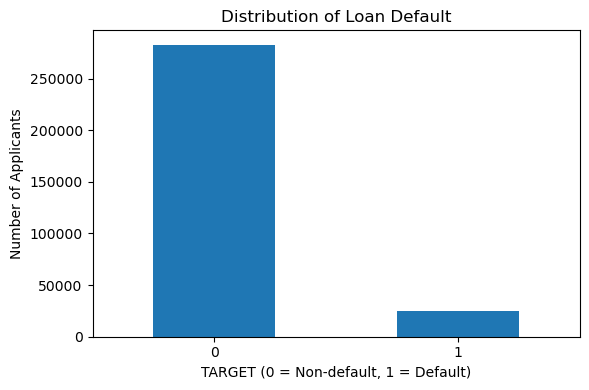

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

target_summary = pd.DataFrame({
    "Count": train_df["TARGET"].value_counts().sort_index(),
    "Percentage": (
        train_df["TARGET"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
})

display(target_summary.round(2))

plt.figure(figsize=(6, 4))

train_df["TARGET"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Loan Default")
plt.xlabel("TARGET (0 = Non-default, 1 = Default)")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
comparison_rows = []

for feature in fe_cols:

    group_0 = train_df.loc[
        train_df["TARGET"] == 0, feature
    ].dropna()

    group_1 = train_df.loc[
        train_df["TARGET"] == 1, feature
    ].dropna()

    comparison_rows.append({
        "Feature": feature,

        "Non_Default_N": len(group_0),
        "Default_N": len(group_1),

        "Non_Default_Mean": group_0.mean(),
        "Default_Mean": group_1.mean(),

        "Non_Default_Median": group_0.median(),
        "Default_Median": group_1.median()
    })


comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

,Feature,Non_Default_N,Default_N,Non_Default_Mean,Default_Mean,Non_Default_Median,Default_Median
0,FE_EMPLOYMENT_UNKNOWN,282686,24825,1.853081e-01,1.204431e-01,0.000000,0.000000
1,FE_CREDIT_INCOME_RATIO,282686,24825,3.963729e+00,3.887438e+00,3.266653,3.253143
2,FE_ANNUITY_INCOME_RATIO,282686,24825,1.805290e-01,1.854825e-01,0.162280,0.169294
3,FE_CREDIT_ANNUITY_RATIO,282686,24825,2.168680e+01,2.076482e+01,20.000000,20.000000
4,FE_CREDIT_GOODS_RATIO,282686,24825,1.119994e+00,1.151550e+00,1.118800,1.145200
5,FE_INCOME_PER_PERSON,282686,24825,9.330378e+04,9.085795e+04,75000.000000,70500.000000
6,FE_CHILDREN_RATIO,282686,24825,1.242464e-01,1.397952e-01,0.000000,0.000000
7,FE_AGE_YEARS,282686,24825,4.418392e+01,4.075244e+01,43.468857,39.101985
8,FE_EMPLOYED_YEARS,230302,21835,6.675264e+00,4.968977e+00,4.629706,3.367556
9,FE_EMPLOYED_AGE_RATIO,230302,21835,1.596558e-01,1.273881e-01,0.121592,0.093461


In [ ]:
effect_results = []

for feature in fe_cols:

    non_default = train_df.loc[
        train_df["TARGET"] == 0, feature
    ].dropna()

    default = train_df.loc[
        train_df["TARGET"] == 1, feature
    ].dropna()

    mean_0 = non_default.mean()
    mean_1 = default.mean()

    var_0 = non_default.var()
    var_1 = default.var()

    pooled_sd = np.sqrt(
        (var_0 + var_1) / 2
    )

    if pooled_sd == 0 or np.isnan(pooled_sd):
        effect = np.nan
    else:
        effect = (
            mean_1 - mean_0
        ) / pooled_sd

    effect_results.append({
        "Feature": feature,
        "Non_Default_Mean": mean_0,
        "Default_Mean": mean_1,
        "Effect_Size": effect,
        "Absolute_Effect_Size": abs(effect)
    })


effect_df = (
    pd.DataFrame(effect_results)
    .sort_values(
        "Absolute_Effect_Size",
        ascending=False
    )
)

display(effect_df.head(15))

,Feature,Non_Default_Mean,Default_Mean,Effect_Size,Absolute_Effect_Size
10,FE_EXT_SOURCE_MEAN,0.518578,0.430942,-0.805228,0.805228
11,FE_EXT_SOURCE_MIN,0.380865,0.271068,-0.703690,0.703690
12,FE_EXT_SOURCE_MAX,0.647680,0.577401,-0.641663,0.641663
19,FE_CC_UTILIZATION,0.316589,0.474845,0.468712,0.468712
15,FE_BUREAU_DEBT_RATIO,0.276648,0.377163,0.327783,0.327783
8,FE_EMPLOYED_YEARS,6.675264,4.968977,-0.292979,0.292979
7,FE_AGE_YEARS,44.183919,40.752438,-0.292881,0.292881
13,FE_EXT_SOURCE_STD,0.139859,0.161407,0.277484,0.277484
9,FE_EMPLOYED_AGE_RATIO,0.159656,0.127388,-0.259063,0.259063
4,FE_CREDIT_GOODS_RATIO,1.119994,1.151550,0.242552,0.242552


In [ ]:
target_corr = (
    train_df[fe_cols + ["TARGET"]]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
)

target_corr_df = pd.DataFrame({
    "Correlation": target_corr,
    "Absolute_Correlation": target_corr.abs()
})

target_corr_df = target_corr_df.sort_values(
    "Absolute_Correlation",
    ascending=False
)

display(target_corr_df.head(15))

,Correlation,Absolute_Correlation
FE_EXT_SOURCE_MEAN,-0.220840,0.220840
FE_EXT_SOURCE_MIN,-0.192750,0.192750
FE_EXT_SOURCE_MAX,-0.174193,0.174193
FE_CC_UTILIZATION,0.135499,0.135499
FE_BUREAU_DEBT_RATIO,0.091640,0.091640
FE_AGE_YEARS,-0.078239,0.078239
FE_EXT_SOURCE_STD,0.078034,0.078034
FE_EMPLOYED_YEARS,-0.074958,0.074958
FE_CREDIT_GOODS_RATIO,0.068474,0.068474
FE_EMPLOYED_AGE_RATIO,-0.067955,0.067955


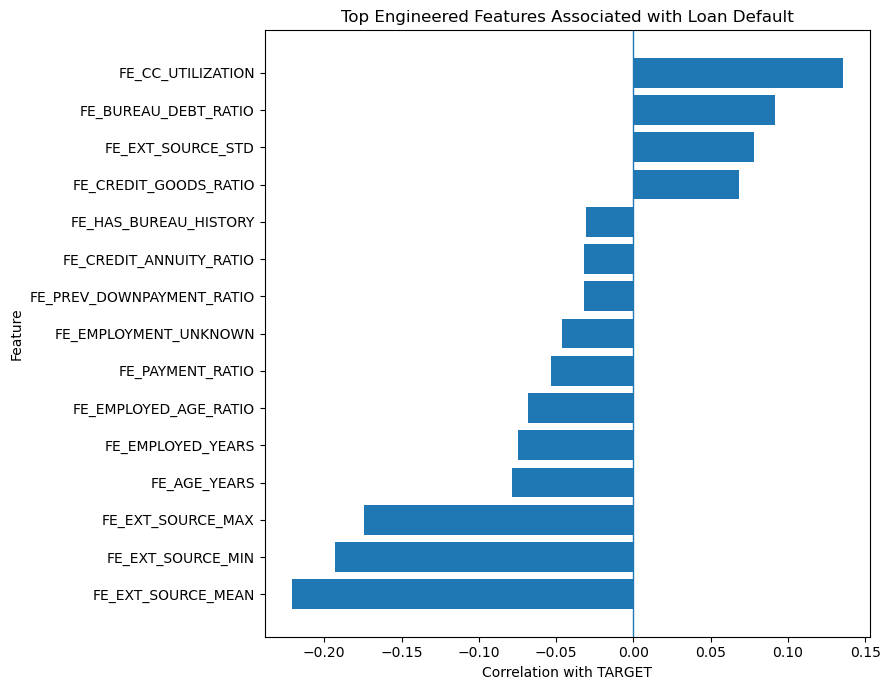

In [ ]:
top_corr = target_corr_df.head(15).sort_values(
    "Correlation"
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_corr.index,
    top_corr["Correlation"]
)

plt.axvline(0, linewidth=1)

plt.title(
    "Top Engineered Features Associated with Loan Default"
)
plt.xlabel("Correlation with TARGET")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu

test_results = []

for feature in fe_cols:

    group_0 = train_df.loc[
        train_df["TARGET"] == 0, feature
    ].dropna()

    group_1 = train_df.loc[
        train_df["TARGET"] == 1, feature
    ].dropna()

    if len(group_0) == 0 or len(group_1) == 0:
        continue

    stat, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided"
    )

    test_results.append({
        "Feature": feature,
        "U_Statistic": stat,
        "P_Value": p_value
    })


stat_test_df = pd.DataFrame(test_results)

# Merge statistical significance with effect sizes
statistical_summary = effect_df.merge(
    stat_test_df,
    on="Feature",
    how="left"
)

display(
    statistical_summary[
        [
            "Feature",
            "Non_Default_Mean",
            "Default_Mean",
            "Effect_Size",
            "Absolute_Effect_Size",
            "P_Value"
        ]
    ].head(15)
)

,Feature,Non_Default_Mean,Default_Mean,Effect_Size,Absolute_Effect_Size,P_Value
0,FE_EXT_SOURCE_MEAN,0.518578,0.430942,-0.805228,0.805228,0.000000e+00
1,FE_EXT_SOURCE_MIN,0.380865,0.271068,-0.703690,0.703690,0.000000e+00
2,FE_EXT_SOURCE_MAX,0.647680,0.577401,-0.641663,0.641663,0.000000e+00
3,FE_CC_UTILIZATION,0.316589,0.474845,0.468712,0.468712,8.638628e-305
4,FE_BUREAU_DEBT_RATIO,0.276648,0.377163,0.327783,0.327783,0.000000e+00
5,FE_EMPLOYED_YEARS,6.675264,4.968977,-0.292979,0.292979,0.000000e+00
6,FE_AGE_YEARS,44.183919,40.752438,-0.292881,0.292881,0.000000e+00
7,FE_EXT_SOURCE_STD,0.139859,0.161407,0.277484,0.277484,0.000000e+00
8,FE_EMPLOYED_AGE_RATIO,0.159656,0.127388,-0.259063,0.259063,8.488502e-255
9,FE_CREDIT_GOODS_RATIO,1.119994,1.151550,0.242552,0.242552,2.638030e-299


In [ ]:
corr_matrix = train_df[fe_cols].corr()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) >= 0.80:
            high_corr_pairs.append({
                "Feature_1": corr_matrix.columns[i],
                "Feature_2": corr_matrix.columns[j],
                "Correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if len(high_corr_df) > 0:
    high_corr_df["Absolute_Correlation"] = (
        high_corr_df["Correlation"].abs()
    )

    high_corr_df = high_corr_df.sort_values(
        "Absolute_Correlation",
        ascending=False
    )

display(high_corr_df)

,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,FE_EMPLOYED_YEARS,FE_EMPLOYED_AGE_RATIO,0.954679,0.954679
3,FE_HAS_PREV_HISTORY,FE_HAS_INSTALLMENT_HISTORY,0.920558,0.920558
4,FE_HAS_POS_HISTORY,FE_HAS_INSTALLMENT_HISTORY,0.906563,0.906563
2,FE_HAS_PREV_HISTORY,FE_HAS_POS_HISTORY,0.879959,0.879959
1,FE_EXT_SOURCE_MEAN,FE_EXT_SOURCE_MIN,0.861130,0.861130


In [ ]:
from scipy.stats import chi2_contingency

categorical_cols = train_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_cols = [
    col for col in categorical_cols
    if col != "dataset_source"
]


def cramers_v(x, y):

    table = pd.crosstab(x, y)

    chi2 = chi2_contingency(table)[0]

    n = table.values.sum()

    phi2 = chi2 / n

    r, k = table.shape

    # Bias correction
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(kcorr - 1, rcorr - 1)

    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2corr / denominator)


categorical_results = []

for col in categorical_cols:

    contingency = pd.crosstab(
        train_df[col],
        train_df["TARGET"]
    )

    chi2, p, dof, expected = chi2_contingency(
        contingency
    )

    categorical_results.append({
        "Feature": col,
        "Unique_Categories": train_df[col].nunique(),
        "Cramers_V": cramers_v(
            train_df[col],
            train_df["TARGET"]
        ),
        "P_Value": p
    })


categorical_assoc_df = (
    pd.DataFrame(categorical_results)
    .sort_values("Cramers_V", ascending=False)
)

display(categorical_assoc_df)

,Feature,Unique_Categories,Cramers_V,P_Value
9,OCCUPATION_TYPE,19,0.079776,0.000000e+00
11,ORGANIZATION_TYPE,58,0.071048,5.224541e-299
5,NAME_INCOME_TYPE,8,0.063667,1.928146e-266
6,NAME_EDUCATION_TYPE,5,0.057458,2.447681e-219
1,CODE_GENDER,3,0.054661,1.129022e-200
14,WALLSMATERIAL_MODE,8,0.043878,3.916842e-125
15,EMERGENCYSTATE_MODE,3,0.042136,1.019821e-119
13,HOUSETYPE_MODE,4,0.040581,4.369310e-110
7,NAME_FAMILY_STATUS,6,0.040311,7.744842e-107
8,NAME_HOUSING_TYPE,6,0.036761,1.099089e-88


In [ ]:
top_categorical = (
    categorical_assoc_df
    .head(5)["Feature"]
    .tolist()
)

for feature in top_categorical:

    summary = (
        train_df
        .groupby(feature)["TARGET"]
        .agg(
            Applicants="size",
            Defaults="sum",
            Default_Rate="mean"
        )
    )

    summary["Default_Rate_%"] = (
        summary["Default_Rate"] * 100
    )

    summary = summary.sort_values(
        "Default_Rate_%",
        ascending=False
    )

    print("\n" + "=" * 70)
    print(feature)
    print("=" * 70)

    display(summary)


OCCUPATION_TYPE


,Applicants,Defaults,Default_Rate,Default_Rate_%
OCCUPATION_TYPE,,,,
Low-skill Laborers,2093,359,0.171524,17.152413
Drivers,18603,2107,0.113261,11.326130
Waiters/barmen staff,1348,152,0.112760,11.275964
Security staff,6721,722,0.107424,10.742449
Laborers,55186,5838,0.105788,10.578770
Cooking staff,5946,621,0.104440,10.443996
Sales staff,32102,3092,0.096318,9.631799
Cleaning staff,4653,447,0.096067,9.606705
Realty agents,751,59,0.078562,7.856192



ORGANIZATION_TYPE


,Applicants,Defaults,Default_Rate,Default_Rate_%
ORGANIZATION_TYPE,,,,
Transport: type 3,1187,187,0.157540,15.754002
Industry: type 13,67,9,0.134328,13.432836
Industry: type 8,24,3,0.125000,12.500000
Restaurant,1811,212,0.117062,11.706240
Construction,6721,785,0.116798,11.679810
Cleaning,260,29,0.111538,11.153846
Industry: type 1,1039,115,0.110683,11.068335
Industry: type 3,3278,348,0.106162,10.616229
Realtor,396,42,0.106061,10.606061



NAME_INCOME_TYPE


,Applicants,Defaults,Default_Rate,Default_Rate_%
NAME_INCOME_TYPE,,,,
Maternity leave,5,2,0.400000,40.000000
Unemployed,22,8,0.363636,36.363636
Working,158774,15224,0.095885,9.588472
Commercial associate,71617,5360,0.074843,7.484257
State servant,21703,1249,0.057550,5.754965
Pensioner,55362,2982,0.053864,5.386366
Businessman,10,0,0.000000,0.000000
Student,18,0,0.000000,0.000000



NAME_EDUCATION_TYPE


,Applicants,Defaults,Default_Rate,Default_Rate_%
NAME_EDUCATION_TYPE,,,,
Lower secondary,3816,417,0.109277,10.927673
Secondary / secondary special,218391,19524,0.089399,8.939929
Incomplete higher,10277,872,0.084850,8.484966
Higher education,74863,4009,0.053551,5.355115
Academic degree,164,3,0.018293,1.829268



CODE_GENDER


,Applicants,Defaults,Default_Rate,Default_Rate_%
CODE_GENDER,,,,
M,105059,10655,0.101419,10.141920
F,202448,14170,0.069993,6.999328
XNA,4,0,0.000000,0.000000


In [ ]:
display(categorical_assoc_df)
display(high_corr_df)

,Feature,Unique_Categories,Cramers_V,P_Value
9,OCCUPATION_TYPE,19,0.079776,0.000000e+00
11,ORGANIZATION_TYPE,58,0.071048,5.224541e-299
5,NAME_INCOME_TYPE,8,0.063667,1.928146e-266
6,NAME_EDUCATION_TYPE,5,0.057458,2.447681e-219
1,CODE_GENDER,3,0.054661,1.129022e-200
14,WALLSMATERIAL_MODE,8,0.043878,3.916842e-125
15,EMERGENCYSTATE_MODE,3,0.042136,1.019821e-119
13,HOUSETYPE_MODE,4,0.040581,4.369310e-110
7,NAME_FAMILY_STATUS,6,0.040311,7.744842e-107
8,NAME_HOUSING_TYPE,6,0.036761,1.099089e-88


,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,FE_EMPLOYED_YEARS,FE_EMPLOYED_AGE_RATIO,0.954679,0.954679
3,FE_HAS_PREV_HISTORY,FE_HAS_INSTALLMENT_HISTORY,0.920558,0.920558
4,FE_HAS_POS_HISTORY,FE_HAS_INSTALLMENT_HISTORY,0.906563,0.906563
2,FE_HAS_PREV_HISTORY,FE_HAS_POS_HISTORY,0.879959,0.879959
1,FE_EXT_SOURCE_MEAN,FE_EXT_SOURCE_MIN,0.861130,0.861130


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance

# deleting extra copies of the data to save RAM
del df

### Preparing the Data

Models only work with numbers, so the text columns (like education or occupation) are turned into 0/1 columns using one-hot encoding.

Train and test are encoded together so both end up with exactly the same columns. Then we separate them again:
- **X**: the features of the training applicants
- **y**: the TARGET (1 = default, 0 = repaid)
- **X_kaggle**: the Kaggle test applicants, which have no TARGET

In [ ]:
full = pd.concat([train_df.drop(columns=['TARGET']), test_df])
cat_cols = full.select_dtypes(include='object').columns.drop('dataset_source')
full = pd.get_dummies(full, columns=cat_cols, prefix_sep='__', dtype='uint8')

X = full[full['dataset_source'] == 'train'].drop(columns=['SK_ID_CURR', 'dataset_source']).astype('float32')
X_kaggle = full[full['dataset_source'] == 'test'].drop(columns=['SK_ID_CURR', 'dataset_source']).astype('float32')
kaggle_ids = test_df['SK_ID_CURR']
y = train_df['TARGET']
del full

print(X.shape, X_kaggle.shape)

(307511, 324) (48744, 324)


### Train/Test Split and Missing Values

**80% training** and **20% testing**. The test set is kept aside and only used at the end, so the final score shows how the model performs on applicants it has never seen.

Missing values are filled with the median of the training data only. If we used the whole dataset, information from the test set would leak into training (data leakage) and the score would look better than it really is.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

medians = X_train.median()
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)
X_kaggle = X_kaggle.fillna(medians)

app_columns = pd.read_csv('data/application_train.csv', nrows=0).columns
base_cols = [c for c in X.columns if c.split('__')[0] in app_columns]

print("all features:", X.shape[1])
print("application table only:", len(base_cols))

all features: 324
application table only: 249


### Baseline Model: Logistic Regression (Application Table Only)


In [ ]:
scaler = StandardScaler()
X_train_base = scaler.fit_transform(X_train[base_cols])
X_test_base = scaler.transform(X_test[base_cols])

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_base, y_train)
baseline_pred = logreg.predict_proba(X_test_base)[:, 1]
baseline_auc = roc_auc_score(y_test, baseline_pred)
print("Baseline ROC-AUC:", round(baseline_auc, 4))

Baseline ROC-AUC: 0.7486


### Random Forest (All 7 Tables)


In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=50,
                            class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred)
print("Random Forest ROC-AUC:", round(rf_auc, 4))

Random Forest ROC-AUC: 0.7623


### Gradient Boosting: Choosing the Learning Rate
Using `HistGradientBoostingClassifier` because it is much faster than the normal `GradientBoostingClassifier`.

To choose a good learning rate, we try three values on a **validation set** taken from the training data. We do not use the test set for this, because choosing settings based on the test set would make the final score unfair.

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

for lr in [0.03, 0.05, 0.1]:
    gb = HistGradientBoostingClassifier(learning_rate=lr, max_iter=1000, random_state=42)
    gb.fit(X_tr, y_tr)
    print("learning rate", lr, "-> validation ROC-AUC:", round(roc_auc_score(y_val, gb.predict_proba(X_val)[:, 1]), 4))

learning rate 0.03 -> validation ROC-AUC: 0.7764
learning rate 0.05 -> validation ROC-AUC: 0.7758
learning rate 0.1 -> validation ROC-AUC: 0.7749


In [ ]:
best_lr = 0.05

gb = HistGradientBoostingClassifier(learning_rate=best_lr, max_iter=1000, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict_proba(X_test)[:, 1]
gb_auc = roc_auc_score(y_test, gb_pred)
print("Gradient Boosting ROC-AUC:", round(gb_auc, 4))


Gradient Boosting ROC-AUC: 0.7826


### Comparing the Models

This table shows the before/after effect of our work: the baseline uses only the application table, while the other two models use all 7 tables.

For ROC Cueve plot, higher the curve, the better the model. The dashed diagonal line is random guessing.

                                    Model   ROC-AUC
0  Logistic Regression (application only)  0.748626
1              Random Forest (all tables)  0.762264
2          Gradient Boosting (all tables)  0.782587

Improvement over baseline: 0.034


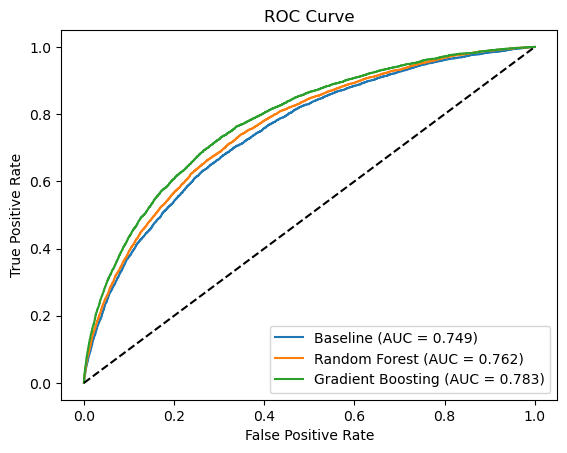

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression (application only)', 'Random Forest (all tables)', 'Gradient Boosting (all tables)'],
    'ROC-AUC': [baseline_auc, rf_auc, gb_auc]
})
print(results)
print("\nImprovement over baseline:", round(gb_auc - baseline_auc, 4))

# ROC curves
for name, pred in [('Baseline', baseline_pred), ('Random Forest', rf_pred), ('Gradient Boosting', gb_pred)]:
    fpr, tpr, _ = roc_curve(y_test, pred)
    plt.plot(fpr, tpr, label=name + ' (AUC = ' + str(round(roc_auc_score(y_test, pred), 3)) + ')')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### Which Features Matter Most?

**Permutation importance**: each feature is shuffled one at a time, and we measure how much the ROC-AUC drops. A big drop means the model relies heavily on that feature.

FE_EXT_SOURCE_MEAN            0.090841
AMT_ANNUITY                   0.006482
FE_CREDIT_GOODS_RATIO         0.005965
FE_CREDIT_ANNUITY_RATIO       0.005945
FE_PAYMENT_RATIO              0.004927
CNT_INSTALMENT_FUTURE_MEAN    0.004400
FE_CC_UTILIZATION             0.004217
CODE_GENDER__M                0.003349
AMT_PAYMENT_SUM               0.003118
EXT_SOURCE_1                  0.002658
AMT_CREDIT_SUM_MEAN           0.002506
FE_BUREAU_DEBT_RATIO          0.002492
DAYS_CREDIT_MEAN              0.002331
FLAG_OWN_CAR__N               0.002318
DAYS_BIRTH                    0.002203
dtype: float64


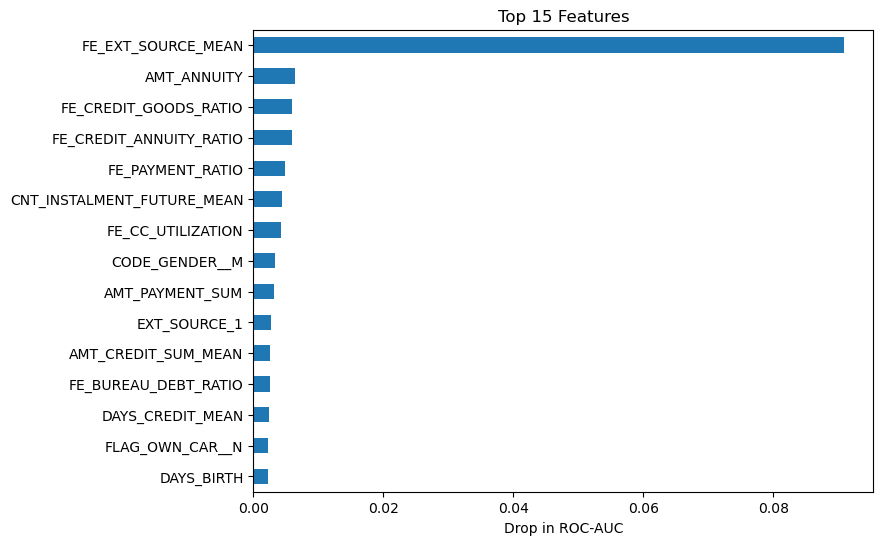

In [ ]:
X_small, _, y_small, _ = train_test_split(X_test, y_test, train_size=0.1, stratify=y_test, random_state=42)
perm = permutation_importance(gb, X_small, y_small, scoring='roc_auc', n_repeats=3, random_state=42)

importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print(importance.head(15))

importance.head(15).sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Features')
plt.xlabel('Drop in ROC-AUC')
plt.show()

### Interpretation:
The mean external credit score is by far the most important feature (about 14 times more than the next one). After that come features about how the loan is structured (annuity, credit/goods ratio, credit/annuity ratio) and past repayment behaviour (payment ratio, installments paid and remaining). Credit card utilisation and debt at other banks also matter.

7 of the top 15 features are engineered features, and most come from the history tables. This shows that using the applicant's full history improves the prediction. It also makes sense from a lending view: people with low credit scores, heavy loan burdens or weak repayment history are more likely to default.

Gender also appears in the top 15. It is predictive, but using it for lending decisions could be unfair or illegal, so this is a limitation of the model.